In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field


In [5]:
load_dotenv()

model = ChatGoogleGenerativeAI(model = 'gemini-2.5-flash')

In [8]:
class SchemaReview(BaseModel):
    sentiment: Literal['positive', 'negative'] = Field(description="Sentiment of the review")

In [9]:
class StateReview(TypedDict):
    review: str
    sentiment: Literal['positive', 'negative']
    diagnosis: dict
    reponse: str

In [10]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [11]:
structure_model = model.with_structured_output(SchemaReview)
structure_model2 = model.with_structured_output(DiagnosisSchema)

In [12]:
prompt = 'What is the sentiment of the following review - The software too good'
structure_model.invoke(prompt).sentiment

'positive'

In [13]:
def get_sentiment(state: StateReview):
    prompt = f'For the following review find out the sentiment \n {state["review"]}'
    sentiment = structure_model.invoke(prompt)

    return {'sentiment': sentiment}

def cond_function(state: StateReview) -> Literal['positive_res', 'run_diagnosis']:
    if state['sentiment'] == 'positive':
        return 'positive_res'
    else:
        return 'run_diagnosis'

def write_p_res(state: StateReview):
    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
    Also, kindly ask the user to leave feedback on our website."""
    reponse = model.invoke(prompt)

    return {'reponse': reponse}

def run_diagnosis(state: StateReview):
    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency."""

    diagnosis = structure_model2.invoke(prompt)
    return {'diagnosis': diagnosis.model_dump()}

def write_n_review(state: StateReview):
    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message."""
    response = model.invoke(prompt)

    return {'response': response}

In [15]:
graph = StateGraph(StateReview)

graph.add_node("sentiment", get_sentiment)
graph.add_node("positive_res", write_p_res)
graph.add_node("run_diagnosis", run_diagnosis)
graph.add_node("negative_res", write_n_review)

graph.add_edge(START, "sentiment")
graph.add_conditional_edges("sentiment", cond_function)
graph.add_edge("positive_res", END)
graph.add_edge("run_diagnosis", "negative_res")
graph.add_edge("negative_res", END)

workflow = graph.compile()

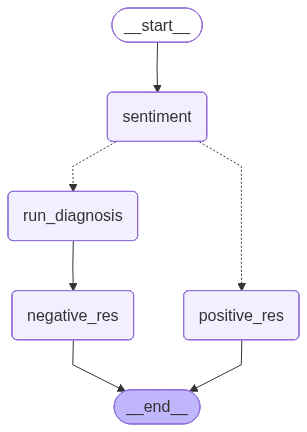

In [16]:
workflow